This step installs the VADER sentiment analysis library. VADER is specifically designed to analyze sentiments in social media text such as tweets. It does not require training and works well for short informal text.

In [1]:
!pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.1 MB/s eta 0:00:00


This step imports all the required Python libraries. Pandas is used for data handling, Matplotlib is used for visualization, and VADER is used to calculate sentiment scores from tweet text.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


This step allows the user to upload the Twitter sentiment dataset (CSV file) into Google Colab. The uploaded file will be used for sentiment analysis.

In [3]:
from google.colab import files
uploaded = files.upload()


Saving twitter.csv to twitter.csv


This step reads the uploaded CSV file into a Pandas DataFrame. The DataFrame is used to view, process, and analyze the tweet text data.

In [4]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


This step creates an instance of the VADER SentimentIntensityAnalyzer. This analyzer is responsible for calculating sentiment scores for each tweet.

In [5]:
analyzer = SentimentIntensityAnalyzer()


This function calculates the sentiment score of each tweet. Based on the compound score, the tweet is classified as Positive, Negative, or Neutral. This classification follows standard VADER thresholds.

In [6]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']

    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"


This step applies the sentiment function to each tweet in the dataset. A new column called "Sentiment" is created to store the sentiment label for every tweet.


In [8]:
df["Sentiment"] = df["tweet"].apply(get_sentiment)
df.head()

,id,label,tweet,Sentiment
0,1,0,@user when a father is dysfunctional and is s...,Negative
1,2,0,@user @user thanks for #lyft credit i can't us...,Positive
2,3,0,bihday your majesty,Neutral
3,4,0,#model i love u take with u all the time in ...,Positive
4,5,0,factsguide: society now #motivation,Positive


This step counts how many tweets fall under each sentiment category (Positive, Negative, Neutral). This helps summarize overall public opinion on social media.

In [9]:
sentiment_counts = df["Sentiment"].value_counts()
sentiment_counts


,count
Sentiment,
Positive,16501
Neutral,8895
Negative,6566


This step creates a bar chart to visually represent the distribution of sentiments in Twitter reviews. Visualization makes it easier to understand public opinion patterns.

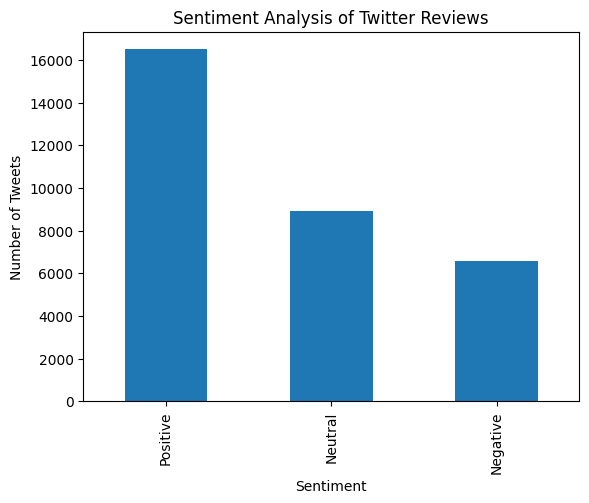

In [10]:
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Analysis of Twitter Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()


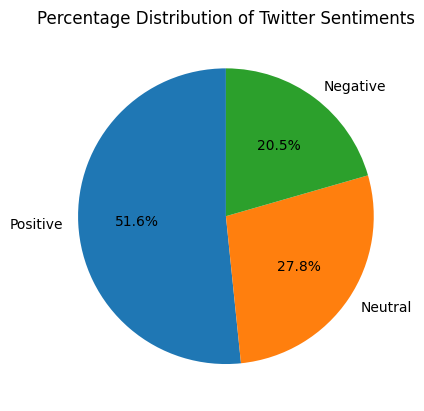

In [12]:
sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of Twitter Sentiments")
plt.ylabel("")
plt.show()


In [14]:
df[["tweet", "Sentiment"]].head(10)


,tweet,Sentiment
0,@user when a father is dysfunctional and is s...,Negative
1,@user @user thanks for #lyft credit i can't us...,Positive
2,bihday your majesty,Neutral
3,#model i love u take with u all the time in ...,Positive
4,factsguide: society now #motivation,Positive
5,[2/2] huge fan fare and big talking before the...,Negative
6,@user camping tomorrow @user @user @user @use...,Neutral
7,the next school year is the year for exams.ð...,Negative
8,we won!!! love the land!!! #allin #cavs #champ...,Positive
9,@user @user welcome here ! i'm it's so #gr...,Positive


In [15]:
sentiment_percentage = (sentiment_counts / sentiment_counts.sum()) * 100
sentiment_percentage


,count
Sentiment,
Positive,51.626932
Neutral,27.829923
Negative,20.543145


This task performs sentiment analysis on social media data using Twitter reviews.
The dataset contains tweet text which is analyzed using natural language processing techniques.**VADER sentiment analysis is applied to classify each tweet as positive, negative, or neutral**.
The results are visualized to understand overall public opinion on social media.